In [2]:
#installed the necessary libraries.

!pip install pandas numpy matplotlib seaborn scikit-learn


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#pandas for the Tables
#numpy to perform mathematical operations
#matplot/seaborn for Graphs (represenations)
#Scikit-learn used here to load the dataset

In [4]:
from sklearn.datasets import fetch_california_housing

california = fetch_california_housing(as_frame=True)

# Used sklearn dataset loader to download the California Housing dataset

# CALIFORNIA DATASET:
# It has 20,640 rows (districts in California)
# Contains features like median income, total rooms, population, latitude, longitude, etc.
# Total there are 8 features and 1 target variable (MedHouseVal → median house price)

In [6]:
# Here we are separating the feature and the target variable.

# X are the features (input variables)
X = california.data

# y is the target variable (what we are predicting)
y = california.target

# Created a new copied dataframe to see both features and target in one table
df = X.copy()

# MedHouseVal is the target variable (Median house value)
df["MedHouseVal"] = y

# Displaying the table to check everything is correct
df.head()

# All variables are numerical, making the dataset suitable for regression analysis

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [7]:
#seeing the size of my dataset.
#20640 rows and 9 columns (13 features and 1 target)

df.shape


(20640, 9)

In [8]:
df.dtypes

#shows all the datatype of the columns in my dataset, important as the regression model can be only used on numbers not string or text.


,0
MedInc,float64
HouseAge,float64
AveRooms,float64
AveBedrms,float64
Population,float64
AveOccup,float64
Latitude,float64
Longitude,float64
MedHouseVal,float64


In [9]:
df.describe()

#The describe() function tells the mean, minimum, maximum, and standard deviation for each feature.

#tells that if there is any extreme value (outlier) or the avg house price and many more.

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


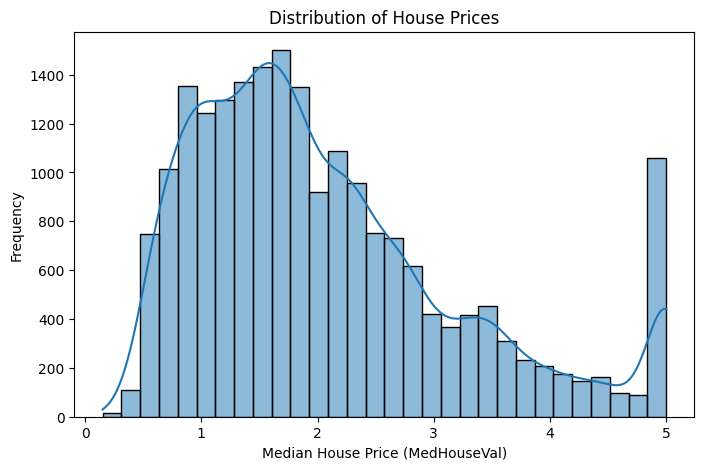

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df["MedHouseVal"], bins=30, kde=True)

plt.xlabel("Median House Price (MedHouseVal)")
plt.ylabel("Frequency")
plt.title("Distribution of House Prices")

plt.show()

# Checking the spread of house prices (whether they are skewed left or right)

# The distribution shows a right-skewed pattern,
# meaning most houses have moderate prices,
# but a few houses are very expensive.

In [14]:
# Summary of Dataset Characteristics

# The California Housing dataset contains 20,640 observations of districts with features like income, population, rooms, and location.
# There are 8 input features and one target variable (MedHouseVal).
# All features are numerical, making the dataset suitable for regression analysis.
# The target variable represents the median house value in each district.
# Most house prices are concentrated in the mid-range, with some high-value outliers (right-skewed distribution).

In [13]:
#CHECK FOR MISSING VALUES:

df.isnull().sum()

#add all the null columns.

#shows no missing value, dataset has no missing value.

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [15]:
#Missing values were added to show handling techniques. The original dataset contains no missing values.

In [19]:
# Strategies for handling missing values:

# Add missing values artificially
df_missing = df.copy()

df_missing.loc[0:5, "AveRooms"] = np.nan
df_missing.loc[10:15, "Population"] = np.nan


# Strategy 1: MEAN / MEDIAN IMPUTATION

df_imputed = df_missing.copy()

df_imputed["AveRooms"] = df_imputed["AveRooms"].fillna(df_imputed["AveRooms"].mean())
df_imputed["Population"] = df_imputed["Population"].fillna(df_imputed["Population"].median())

# Mean imputation applied to AveRooms
# Median imputation applied to Population


# Strategy 2: Row Removal

df_dropped = df_missing.dropna()

# Rows with missing values are removed
# Suitable only when missing data is small

In [20]:
#COMPARISON:

print("Before Handling Missing Values:")
print(df_missing.isnull().sum())

print("\nAfter Mean/Median Imputation:")
print(df_imputed.isnull().sum())

print("\nAfter Row Removal:")
print(df_dropped.isnull().sum())

#BEFORE:

#Tax and RM had 6 missing values later they were removed.


Before Handling Missing Values:
MedInc         0
HouseAge       0
AveRooms       6
AveBedrms      0
Population     6
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

After Mean/Median Imputation:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

After Row Removal:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [21]:
## Missing Value Handling Justification

#Mean and median were used because they preserve the dataset size and are effective when missing values are minimal.
#Row removal is also done but is only use when missing data is limited, as it reduces the number of rows.

In [23]:
# TASK 3: Outlier Detection & Treatment

# Detect OUTLIERS using IQR (Q3 - Q1)

Q1 = df["MedHouseVal"].quantile(0.25)
Q3 = df["MedHouseVal"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df["MedHouseVal"] < lower_bound) | (df["MedHouseVal"] > upper_bound)]

outliers_iqr.shape

# The IQR method is used to identify outliers in the target variable (MedHouseVal).
# Values below lower_bound or above upper_bound are considered outliers.

(1071, 9)

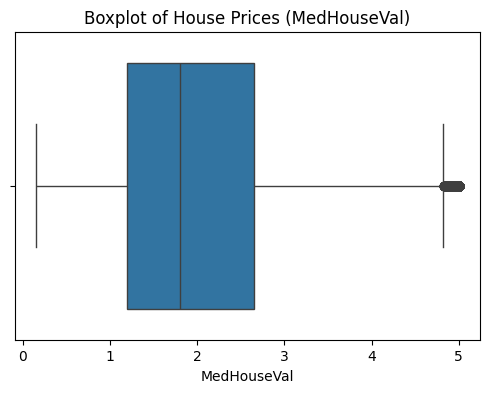

In [25]:
# BOX PLOT:

plt.figure(figsize=(6,4))
sns.boxplot(x=df["MedHouseVal"])

plt.title("Boxplot of House Prices (MedHouseVal)")
plt.show()

# The boxplot shows the presence of outliers,
# especially in the upper range of house prices.

In [27]:
# USE Z-Score:

# RULE: |z| > 3 = outlier

from scipy.stats import zscore

z_scores = zscore(df["MedHouseVal"])
outliers_z = df[abs(z_scores) > 3]

outliers_z.shape

# Z-score analysis is used to detect extreme values.
# Data points with a Z-score greater than 3 are considered outliers.
# Very few or no rows may be detected as outliers depending on distribution.

(0, 9)

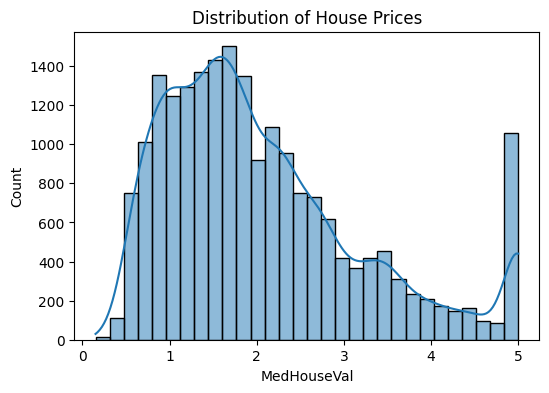

In [28]:
plt.figure(figsize=(6,4))
sns.histplot(df["MedHouseVal"], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.show()

# The distribution is right-skewed,
# meaning most houses have moderate prices,
# while a few houses are very expensive.

In [29]:
# Method to Remove Outliers:

# We are applying Capping (Clipping)

# Justification:
# It keeps all data and limits extreme values, which is good for regression models.

df_capped = df.copy()

df_capped["MedHouseVal"] = np.where(
    df_capped["MedHouseVal"] > upper_bound,
    upper_bound,
    df_capped["MedHouseVal"]
)

# Outliers are treated using capping,
# where extreme values are limited to the upper bound.

In [30]:
# CLEANED DATASET:

df_cleaned = df_capped.copy()
df_cleaned.head()

# FINAL:
# The capped dataset is selected as the cleaned dataset because
# it reduces the impact of outliers without removing any data.

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


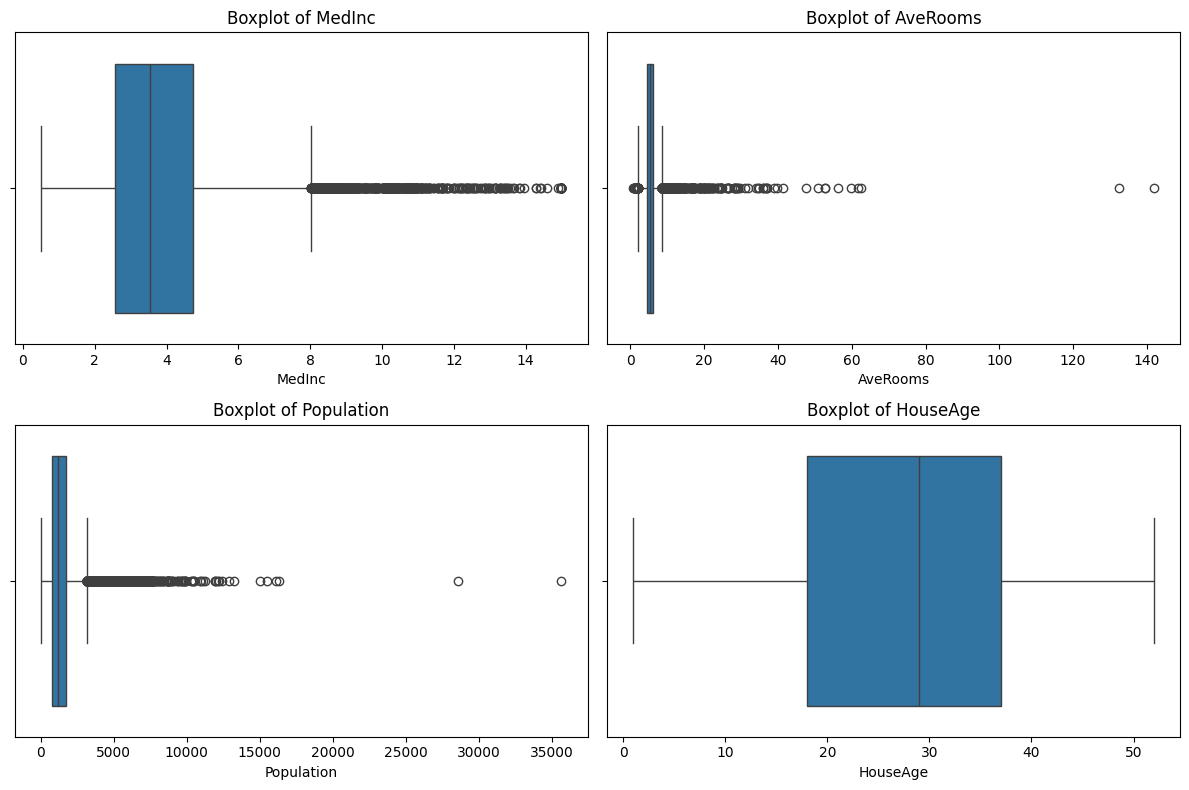

In [31]:
# Check boxplots for important features

features_to_check = ["MedInc", "AveRooms", "Population", "HouseAge"]

plt.figure(figsize=(12,8))

for i, col in enumerate(features_to_check, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df_cleaned[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

In [32]:
df_feature_capped = df_cleaned.copy()

for col in ["MedInc", "AveRooms", "Population"]:
    Q1 = df_feature_capped[col].quantile(0.25)
    Q3 = df_feature_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR

    df_feature_capped[col] = np.where(
        df_feature_capped[col] > upper_bound,
        upper_bound,
        df_feature_capped[col]
    )

In [33]:
df_feature_capped.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.013025,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.013025,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.257400,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.643100,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.846200,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [34]:
# SUMMARY AND JUSTIFICATION:

# Outliers were detected using both IQR and Z-score methods.
# Boxplots and distribution plots were used for visualization.
# Outliers were treated using capping (clipping).
# Capping was applied to the target variable (MedHouseVal) and selected skewed features.
# Features like AveRooms and Population were capped, while relatively stable features were left unchanged.
# Capping was chosen to preserve all data while reducing the impact of extreme values.
# The cleaned dataset is now ready for regression modeling.

In [35]:
X = df_feature_capped.drop("MedHouseVal", axis=1)
y = df_feature_capped["MedHouseVal"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

#made the train test split

In [36]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Intercept (base value when all features = 0)
lr_model.intercept_

# Coefficients (impact of each feature)
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
})

coefficients

,Feature,Coefficient
0,MedInc,0.493037
1,HouseAge,0.010572
2,AveRooms,-0.106650
3,AveBedrms,0.281877
4,Population,-0.000015
5,AveOccup,-0.003125
6,Latitude,-0.396154
7,Longitude,-0.408019


In [37]:
y_pred = lr_model.predict(X_test)
pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10]
})

,Actual,Predicted
0,0.477000,0.671498
1,0.458000,1.650690
2,4.824125,2.632170
3,2.186000,2.959660
4,2.780000,2.615924
5,1.587000,2.105111
6,1.982000,2.738376
7,1.575000,2.199127
8,3.400000,2.758550
9,4.466000,4.151730


In [40]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

evaluation_results = pd.DataFrame({
    "Metric": ["MSE", "RMSE", "R²"],
    "Value": [mse, rmse, r2]
})

evaluation_results

,Metric,Value
0,MSE,0.536546
1,RMSE,0.732493
2,R²,0.575637


In [ ]:
# JUSTIFICATION:

# The model shows moderate performance with an R² value of approximately 0.58.
# This means that about 58% of the variation in house prices is explained by the model.

# The RMSE value of around 0.73 indicates that the prediction error is relatively low,
# suggesting the model makes reasonably accurate predictions.

# The results show that the model is not underfitting severely,
# but there is still room for improvement.

# Since the performance on test data is reasonable,
# the model demonstrates acceptable generalization to unseen data.

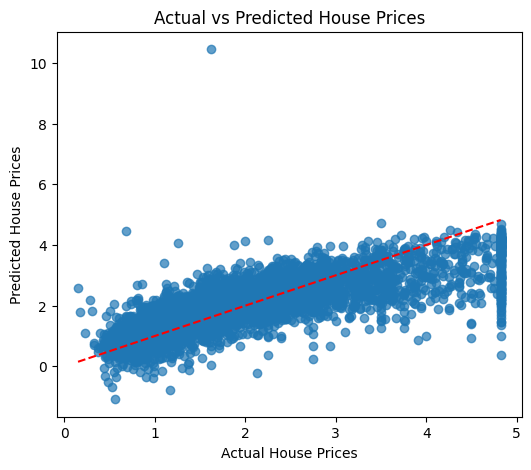

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

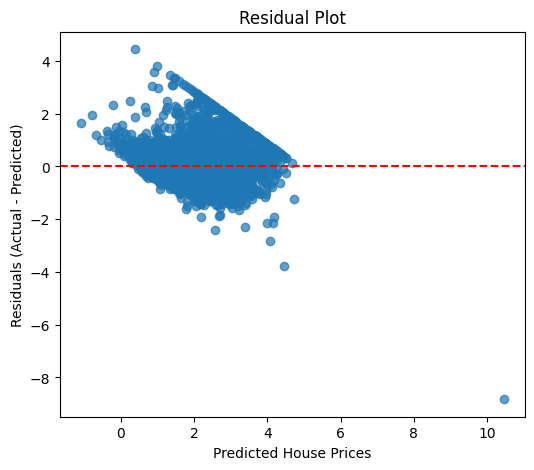

In [42]:
residuals = y_test - y_pred

plt.figure(figsize=(6,5))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted House Prices")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()

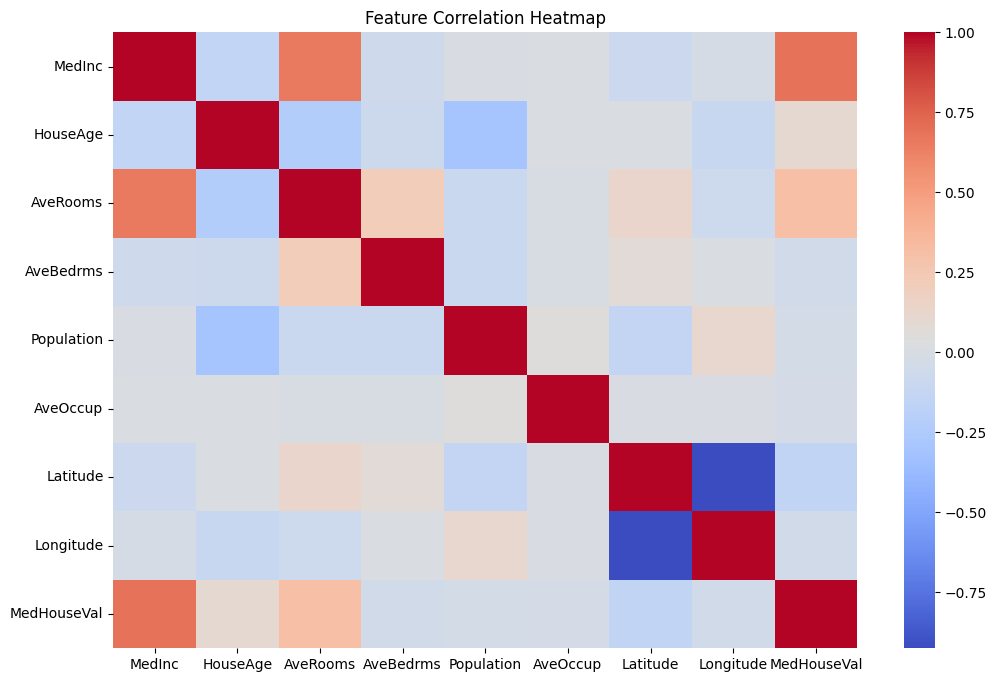

In [43]:
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df_feature_capped.corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)



In [45]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

lr_scaled = LinearRegression()
lr_scaled.fit(X_train_s, y_train_s)

y_pred_scaled = lr_scaled.predict(X_test_s)

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse_scaled = np.sqrt(mean_squared_error(y_test_s, y_pred_scaled))
r2_scaled = r2_score(y_test_s, y_pred_scaled)


print("Model Performance After Feature Scaling:")
print(f"RMSE (Scaled): {rmse_scaled:.3f}")
print(f"R² Score (Scaled): {r2_scaled:.3f}")

Model Performance After Feature Scaling:
RMSE (Scaled): 0.732
R² Score (Scaled): 0.576
